# Phase 7A Level 1：1RC pure DNN 层级复杂度消融

**问题**：在仅含 `(SOC, Vp)`、电流边界和端电压上限的项目参数 1RC 控制问题中，pure DNN 能否稳定逼近 MPC？

成功标准：教师确定性、五种子冻结离线 NRMSE `<1%`、五种子同模型闭环同时通过。Notebook 只读取冻结产物，不重新求解或训练。

## 1. 设置与可复现性

所有数据、配置、模型与指标来自独立的 `phase7a_level1_1rc` 目录。

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
OUT = ROOT / 'outputs' / 'phase7a_level1_1rc'
DATA = ROOT / 'data' / 'phase7a_level1_1rc'
metrics = json.loads((OUT / 'metrics.json').read_text(encoding='utf-8'))
offline = pd.read_csv(OUT / 'dnn_offline_metrics.csv')
closed = pd.read_csv(DATA / 'closed_loop_metrics.csv')
audit = pd.read_csv(DATA / 'multistart_state_summary.csv')
print(metrics['study_name'], metrics['status'])

phase7a_level1_project_1rc_pure_dnn completed


## 2. 教师合同与 100×15 多起点审计

In [2]:
display(pd.DataFrame([metrics['teacher']]))
display(pd.DataFrame([{
    'states': metrics['teacher_audit']['state_count'],
    'warm_starts/state': metrics['teacher_audit']['warm_starts_per_state'],
    'multivalued_fraction': metrics['teacher_audit']['near_optimal_multivalued_fraction'],
    'action_range_p95_A': metrics['teacher_audit']['near_optimal_first_action_range_p95_a'],
    'passed': metrics['teacher_audit']['success'],
}]))
assert len(audit) == 100
assert metrics['teacher_audit']['success']

,attempted_trajectories,accepted_trajectories,acceptance_fraction,sample_count,split_trajectory_counts,success
0,240,240,1.0,1920,"{'test': 36, 'train': 168, 'validation': 36}",True


,states,warm_starts/state,multivalued_fraction,action_range_p95_A,passed
0,100,15,0.0,1.540554e-11,True


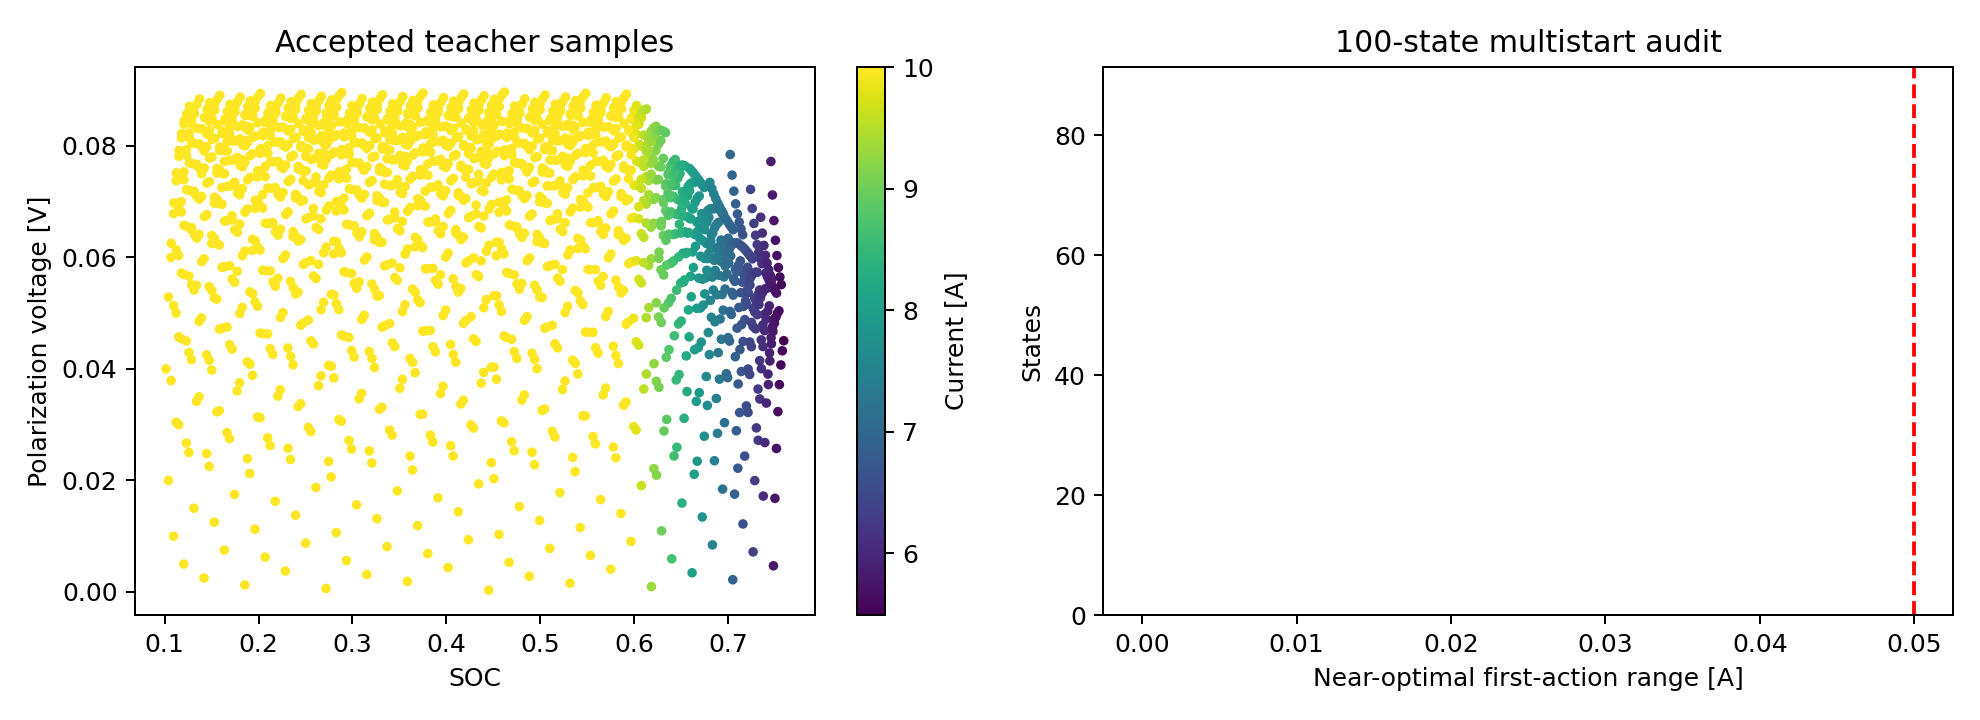

In [3]:
display(Image(filename=str(OUT / 'figures' / 'teacher_and_audit.png')))

## 3. 五种子冻结离线测试

In [4]:
columns = ['seed', 'test_mae_a', 'test_rmse_a', 'test_nrmse', 'test_r2']
view = offline[columns].copy()
view['test_nrmse_percent'] = 100 * view.pop('test_nrmse')
display(view)
assert len(view) == 5
assert (view.test_nrmse_percent < 1.0).all()

,seed,test_mae_a,test_rmse_a,test_r2,test_nrmse_percent
0,22,0.009689,0.012548,0.999899,0.125475
1,42,0.002696,0.006723,0.999971,0.067229
2,73,0.009643,0.011284,0.999919,0.112844
3,101,0.004461,0.009148,0.999946,0.091482
4,137,0.003613,0.008972,0.999949,0.089718


## 4. 25 ℃同模型闭环

,seed,target_reach_fraction,maximum_voltage_violation_v,maximum_current_violation_a,speedup,mean_current_nrmse_percent,mean_charge_time_gap_percent
0,22,1.0,0.0,0.0,2403.960168,8.920982,38.109185
1,42,1.0,0.0,0.0,2478.717909,8.878754,38.109185
2,73,1.0,0.0,0.0,2310.949227,9.072547,38.109185
3,101,1.0,0.0,0.0,2471.272380,8.979621,37.984342
4,137,1.0,0.0,0.0,2510.754990,8.979066,38.109185


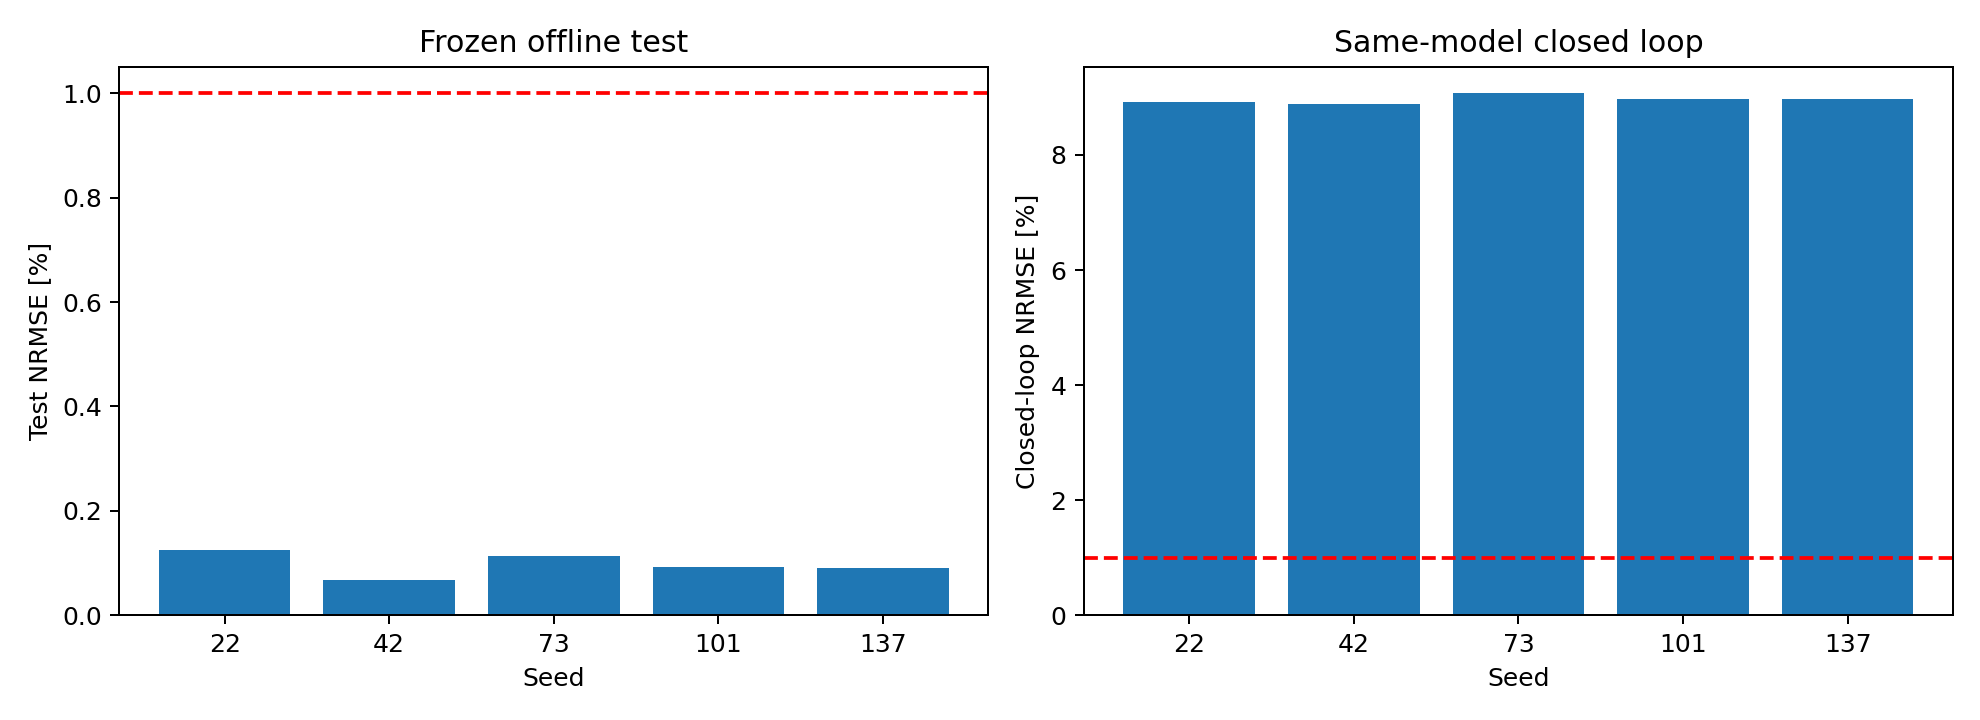

In [5]:
view = closed[['seed','mean_current_nrmse','mean_charge_time_gap_fraction','target_reach_fraction','maximum_voltage_violation_v','maximum_current_violation_a','speedup']].copy()
view['mean_current_nrmse_percent'] = 100 * view.pop('mean_current_nrmse')
view['mean_charge_time_gap_percent'] = 100 * view.pop('mean_charge_time_gap_fraction')
display(view)
display(Image(filename=str(OUT / 'figures' / 'dnn_seed_stability.png')))

## 5. 失败定位

冻结离线测试通过但闭环失败，属于计划中的情况 C。训练轨迹每条仅展开 8 个 5 s 步骤，原始状态上界为 SOC 0.75；其接受样本未覆盖闭环目标 SOC 0.80 附近。DNN 因此在末端区域发生分布外外推，虽然仍满足安全边界并到达目标，却无法复现 MPC 的末端降流策略。

In [6]:
teacher = pd.read_csv(DATA / 'teacher_dataset.csv')
trajectories = pd.read_csv(DATA / 'closed_loop_trajectories.csv')
pd.DataFrame({
    'teacher_state_soc_max': [teacher.state_soc.max()],
    'closed_loop_state_soc_max': [trajectories.soc.max()],
    'teacher_polarization_max_V': [teacher.state_polarization_v.max()],
    'closed_loop_polarization_max_V': [trajectories.polarization_v.max()],
})

,teacher_state_soc_max,closed_loop_state_soc_max,teacher_polarization_max_V,closed_loop_polarization_max_V
0,0.759644,0.799491,0.089632,0.091183


## 6. 阶段判定

In [7]:
display(pd.DataFrame([metrics['decision']['checks']]))
print(metrics['decision']['conclusion'])
print('进入 Level 2:', metrics['decision']['proceed_to_level2'])
assert metrics['status'] == 'completed'
assert metrics['decision']['checks']['teacher_determinism_passed']
assert metrics['decision']['checks']['offline_test_passed']
assert not metrics['decision']['checks']['same_model_closed_loop_passed']
assert not metrics['decision']['proceed_to_level2']

,teacher_determinism_passed,offline_test_passed,same_model_closed_loop_passed
0,True,True,False


Level 1 未通过
进入 Level 2: False


## 下一步

依据预注册停止条件，本轮不进入 Level 2。若继续研究 Level 1，可单独注册一次仅使用训练/验证轨迹的末端覆盖增广；冻结测试集不得参与样本选择，并且该变体须标记为闭环增广 pure DNN，而非原始 Level 1。